# Forecasting ERCOT Electricity Demand & Detecting Distributional Shift

**Question:** Can a simple model forecast short-term ERCOT electricity demand, and — more importantly — can we *detect* when that model breaks during a structural shock (Winter Storm Uri, Feb 2021) and reason about how to respond?

This notebook builds an honest baseline and a linear forecaster, then layers two drift detectors (a performance-based error monitor and an input-distribution PSI monitor) and a triage rule that combines them. The focus is not peak accuracy — it is demonstrating detection and handling of a regime break, which is the core problem in production energy forecasting.

**Data:** Hourly ERCOT demand (MWh) from the EIA API, June 2020 – June 2021.

In [1]:
import os
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

%matplotlib inline

CSV_PATH = Path("data/ercot_demand.csv")
BASE = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

def pull_ercot_demand(start="2020-06-01T00", end="2021-06-01T00"):
    """Pull hourly ERCOT demand (MWh) from EIA API v2, paginated."""
    load_dotenv()
    key = os.environ["EIA_API_KEY"]
    rows, offset = [], 0
    while True:
        params = {
            "api_key": key, "frequency": "hourly", "data[0]": "value",
            "facets[respondent][]": "ERCO", "facets[type][]": "D",
            "start": start, "end": end,
            "sort[0][column]": "period", "sort[0][direction]": "asc",
            "offset": offset, "length": 5000,
        }
        r = requests.get(BASE, params=params, timeout=60)
        r.raise_for_status()
        batch = r.json()["response"]["data"]
        rows.extend(batch)
        if len(batch) < 5000:
            break
        offset += 5000
    df = pd.DataFrame(rows)
    df["period"] = pd.to_datetime(df["period"], format="%Y-%m-%dT%H")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return (df[["period", "value"]]
            .set_index("period").rename(columns={"value": "demand_mwh"}))

# Load from cached CSV if present (reproducible, no key needed);
# otherwise pull from the API and cache it.
if CSV_PATH.exists():
    demand_raw = pd.read_csv(CSV_PATH, parse_dates=["period"]).set_index("period")
    print(f"Loaded cached data: {demand_raw.shape}")
else:
    demand_raw = pull_ercot_demand()
    CSV_PATH.parent.mkdir(exist_ok=True)
    demand_raw.to_csv(CSV_PATH)
    print(f"Pulled from EIA API and cached: {demand_raw.shape}")

Loaded cached data: (8761, 1)


In [2]:
from pathlib import Path
print("CSV exists:", Path("data/ercot_demand.csv").exists())

CSV exists: True


## 1. Clean & verify the series

Hourly grid data can have gaps or duplicates. Rather than dropping silently, we reconstruct the complete hourly index and *report* what's missing — missingness during a grid crisis can itself be informative.

In [3]:
n_dupes = demand_raw.index.duplicated().sum()
demand = demand_raw[~demand_raw.index.duplicated(keep="first")].copy()

full_index = pd.date_range(demand.index.min(), demand.index.max(), freq="h")
missing = full_index.difference(demand.index)
print(f"Duplicates: {n_dupes} | Expected hours: {len(full_index)} | "
      f"Present: {len(demand)} | Missing: {len(missing)}")

demand = demand.reindex(full_index)
demand["demand_mwh"] = demand["demand_mwh"].interpolate(
    method="time", limit=3, limit_area="inside")
demand.index.name = "period"
print(f"Remaining NaN after interpolation: {demand['demand_mwh'].isna().sum()}")
print(f"Final shape: {demand.shape}")

Duplicates: 0 | Expected hours: 8761 | Present: 8761 | Missing: 0
Remaining NaN after interpolation: 0
Final shape: (8761, 1)


## Shared constants

Defined once and reused, so the baseline, model, and evaluation all use an identical split and event window.

In [4]:
SPLIT_DATE = pd.Timestamp("2021-01-01 00:00")   # train before, test on/after
URI_START  = pd.Timestamp("2021-02-11")          # storm onset (data-flagged)
URI_END    = pd.Timestamp("2021-02-18")          # incl. blackout aftermath
SEASON     = 168                                 # weekly lag (hours)

def mape(actual, pred):
    return (np.abs(actual - pred) / np.abs(actual)).mean() * 100

## 2. Exploratory analysis — look before modeling

We plot the full series and run a data-driven anomaly check across the *entire* span (train **and** test), so any structural break is identified from the data rather than assumed — and we confirm the training period isn't contaminated by a major shock.

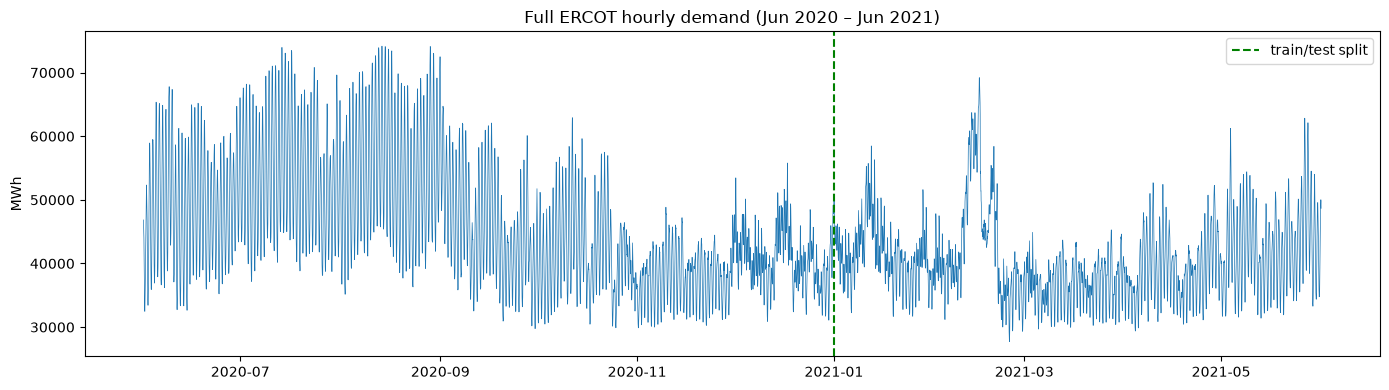

Anomalous days (|z| > 2.5 vs local norm):
  2020-06-01  41,935 MWh  z=-2.9
  2020-09-11  41,049 MWh  z=-2.7
  2020-10-17  36,028 MWh  z=-3.0
  2020-12-17  47,038 MWh  z=+2.6
  2021-02-11  53,639 MWh  z=+3.0
  2021-02-12  59,099 MWh  z=+4.4
  2021-02-13  59,333 MWh  z=+3.5
  2021-02-14  59,722 MWh  z=+3.7

In train (pre-2021-01-01): 4  |  In test: 4


In [5]:
s = demand["demand_mwh"]

plt.figure(figsize=(14, 4))
plt.plot(s.index, s.values, lw=0.5)
plt.axvline(SPLIT_DATE, color="green", ls="--", label="train/test split")
plt.title("Full ERCOT hourly demand (Jun 2020 – Jun 2021)")
plt.ylabel("MWh"); plt.legend(); plt.tight_layout(); plt.show()

# Data-driven anomaly flag vs a local 14-day seasonal norm
daily = s.resample("D").mean()
local_norm = daily.rolling(14, center=True, min_periods=7).median()
z = (daily - local_norm)
z = (z - z.mean()) / z.std()
anomalies = daily[np.abs(z) > 2.5]
print("Anomalous days (|z| > 2.5 vs local norm):")
for d, v in anomalies.items():
    print(f"  {d.date()}  {v:,.0f} MWh  z={z[d]:+.1f}")
print(f"\nIn train (pre-{SPLIT_DATE.date()}): {(anomalies.index < SPLIT_DATE).sum()}"
      f"  |  In test: {(anomalies.index >= SPLIT_DATE).sum()}")

## 3. Train/test split + seasonal-naive baseline

Time-ordered split (never shuffled). The baseline is "demand = same hour one week ago" (168h lag), which captures daily and weekly cycles and is a genuinely hard bar to beat. Uri sits in the **test** set so we study a model trained on normal conditions meeting a shock.

In [6]:
train = demand.loc[demand.index <  SPLIT_DATE]
test  = demand.loc[demand.index >= SPLIT_DATE]
print(f"Train: {train.index.min()} → {train.index.max()} ({len(train)} hrs)")
print(f"Test:  {test.index.min()} → {test.index.max()} ({len(test)} hrs)")

naive_pred = s.shift(SEASON)
eval_df = pd.DataFrame({"actual": test["demand_mwh"],
                        "naive": naive_pred.loc[test.index]}).dropna()
print(f"\nSeasonal-naive baseline MAPE (full test): "
      f"{mape(eval_df['actual'], eval_df['naive']):.2f}%")

Train: 2020-06-01 00:00:00 → 2020-12-31 23:00:00 (5136 hrs)
Test:  2021-01-01 00:00:00 → 2021-06-01 00:00:00 (3625 hrs)

Seasonal-naive baseline MAPE (full test): 11.18%


## 4. Feature engineering + linear forecaster

Features are derived only from the timestamp and demand history: hour-of-day and day-of-week (one-hot), plus the weekly lag. Deliberately simple and interpretable — the goal is a defensible baseline forecaster, not maximum accuracy. (No weather features; this is a stated limitation.)

In [7]:
from sklearn.linear_model import LinearRegression

def make_features(series):
    df = pd.DataFrame(index=series.index)
    df["lag_168"] = series.shift(SEASON)
    hour, dow = series.index.hour, series.index.dayofweek
    for h in range(24):
        df[f"hr_{h}"] = (hour == h).astype(int)
    for d in range(7):
        df[f"dow_{d}"] = (dow == d).astype(int)
    df["target"] = series.values
    return df

feat = make_features(s).dropna()
train_f = feat.loc[feat.index <  SPLIT_DATE]
test_f  = feat.loc[feat.index >= SPLIT_DATE]
cols = [c for c in feat.columns if c != "target"]

model = LinearRegression().fit(train_f[cols], train_f["target"])
test_f = test_f.copy()
test_f["pred_model"] = model.predict(test_f[cols])
print(f"Linear model MAPE (full test):   "
      f"{mape(test_f['target'], test_f['pred_model']):.2f}%")

Linear model MAPE (full test):   10.68%


## 5. Error by regime — how much does the shock hurt?

Splitting forecast error into normal periods vs the Uri window quantifies the degradation. Both models roughly double their error during Uri — and the right reading is that *no* model trained on normal data should be trusted through such an event.

In [8]:
results = test_f[["target", "pred_model"]].copy()
results["pred_naive"] = s.shift(SEASON).loc[results.index]
results = results.dropna()
is_uri = (results.index >= URI_START) & (results.index <= URI_END)

def pair(df):
    return (mape(df["target"], df["pred_model"]),
            mape(df["target"], df["pred_naive"]))

mn, nn = pair(results[~is_uri])
mu, nu = pair(results[is_uri])
ma, na = pair(results)
print("                   Linear    Naive")
print(f"Normal (excl Uri)  {mn:5.2f}%   {nn:5.2f}%")
print(f"Uri window         {mu:5.2f}%   {nu:5.2f}%")
print(f"Full test          {ma:5.2f}%   {na:5.2f}%")
print(f"\nUri hours: {is_uri.sum()} | Normal hours: {(~is_uri).sum()}")

                   Linear    Naive
Normal (excl Uri)  10.03%   10.47%
Uri window         23.89%   25.71%
Full test          10.68%   11.18%

Uri hours: 169 | Normal hours: 3456


## 6. Drift monitor #1 — forecast error (causal, anomaly-aware)

A production-style monitor: it alarms when rolling forecast error exceeds a threshold built from a trailing window of **only prior, non-anomalous** data. The `.shift(1)` and clean-history

First error-monitor breach: 2021-01-11 05:00:00
Total hours in breach: 532


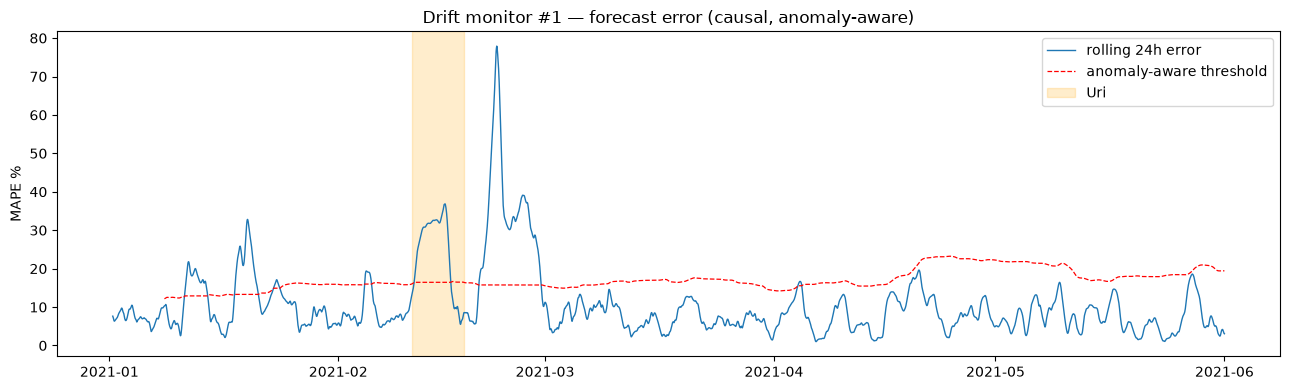

In [9]:
results["ape_model"] = (np.abs(results["target"] - results["pred_model"])
                        / np.abs(results["target"]) * 100)
roll = results["ape_model"].rolling(24, min_periods=12).mean().dropna()

WIN, MIN_HIST, K = 24*21, 24*7, 3.0
clean_history = []
alarm_level = pd.Series(index=roll.index, dtype=float)
breach_flag = pd.Series(False, index=roll.index)

for ts, err in roll.items():
    if len(clean_history) >= MIN_HIST:
        recent = np.array(clean_history[-WIN:])
        thr = recent.mean() + K * recent.std()
        alarm_level[ts] = thr
        if err > thr:
            breach_flag[ts] = True
            continue              # breach excluded from baseline (no poisoning)
    clean_history.append(err)

print(f"First error-monitor breach: {breach_flag[breach_flag].index.min()}")
print(f"Total hours in breach: {breach_flag.sum()}")

plt.figure(figsize=(13, 4))
plt.plot(roll.index, roll.values, lw=1, label="rolling 24h error")
plt.plot(alarm_level.index, alarm_level.values, color="red", ls="--", lw=0.9,
         label="anomaly-aware threshold")
plt.axvspan(URI_START, URI_END, color="orange", alpha=0.2, label="Uri")
plt.title("Drift monitor #1 — forecast error (causal, anomaly-aware)")
plt.ylabel("MAPE %"); plt.legend(); plt.tight_layout(); plt.show()

## 7. Drift monitor #2 — input distribution (PSI)

PSI measures how far the recent demand distribution has drifted from a reference (calm January). It uses a 7-day window (one weekly cycle; stable yet responsive) and 5 bins (small windows under-populate more bins). The threshold is calibrated to the observed normal range, not a textbook default. This is a *leading-ish* signal — it watches inputs, not error.

*Limitation:* the reference is fixed at January, so PSI stays elevated into spring as the season changes — in production the reference would be refreshed periodically.

Calibrated PSI threshold: 1.14
First PSI crossing (post warm-up): 2021-02-15 00:00:00
Max PSI: 8.26 on 2021-02-18


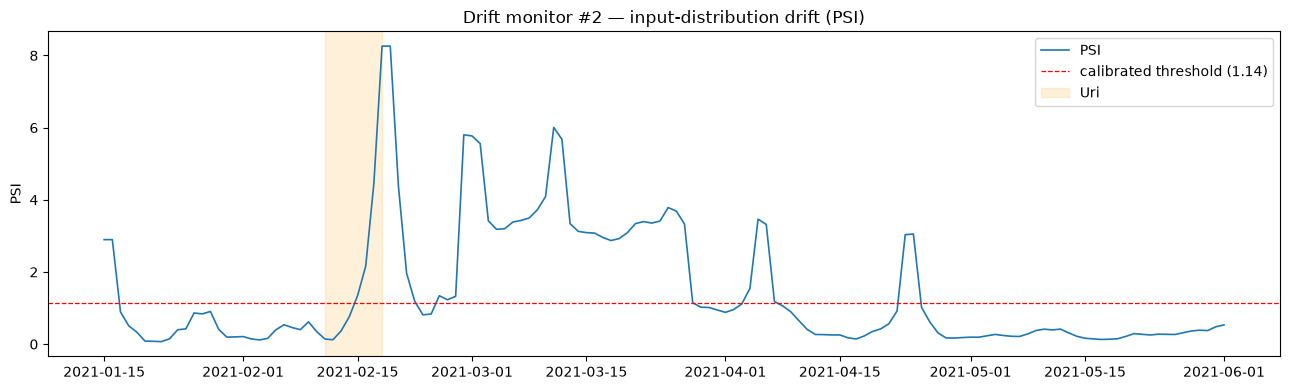

In [10]:
def psi(reference, current, bins=5):
    edges = np.quantile(reference, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    ref = np.histogram(reference, edges)[0] / len(reference)
    cur = np.histogram(current,  edges)[0] / len(current)
    ref = np.where(ref == 0, 1e-6, ref)
    cur = np.where(cur == 0, 1e-6, cur)
    return np.sum((cur - ref) * np.log(cur / ref))

reference = s.loc["2021-01-01":"2021-01-31"].values
psi_series = {}
for day in pd.date_range("2021-01-15", "2021-06-01", freq="D"):
    window = s.loc[day - pd.Timedelta(days=7):day].values
    if len(window) >= 100:
        psi_series[day] = psi(reference, window)
psi_series = pd.Series(psi_series)

calm = psi_series.loc["2021-01-18":"2021-02-07"]
psi_threshold = calm.mean() + 3 * calm.std()
settled = psi_series.loc["2021-01-25":]
print(f"Calibrated PSI threshold: {psi_threshold:.2f}")
print(f"First PSI crossing (post warm-up): "
      f"{settled[settled > psi_threshold].index.min()}")
print(f"Max PSI: {psi_series.max():.2f} on {psi_series.idxmax().date()}")

plt.figure(figsize=(13, 4))
plt.plot(psi_series.index, psi_series.values, lw=1.2, label="PSI")
plt.axhline(psi_threshold, color="red", ls="--", lw=0.9,
            label=f"calibrated threshold ({psi_threshold:.2f})")
plt.axvspan(URI_START, URI_END, color="orange", alpha=0.15, label="Uri")
plt.title("Drift monitor #2 — input-distribution drift (PSI)")
plt.ylabel("PSI"); plt.legend(); plt.tight_layout(); plt.show()

## 8. Triage — combine both signals

A single detector firing isn't enough to act. We require **both** signals on the same day to mark drift **CONFIRMED**; one signal alone is **WATCH**. The strict same-day rule is deliberately un-tunable. The resulting WATCH/CONFIRMED alternation through Uri is itself informative: error fires before PSI's window fills (Feb 11–14), and PSI persists while error drops during the blackout suppression (Feb 17–19).

In [11]:
error_daily = breach_flag.resample("D").max()
psi_breach  = psi_series > psi_threshold

triage = pd.DataFrame({"error_alarm": error_daily,
                       "psi_alarm": psi_breach}).dropna()
triage["error_alarm"] = triage["error_alarm"].fillna(False).astype(bool)
triage["psi_alarm"]   = triage["psi_alarm"].fillna(False).astype(bool)

def state(r):
    if r["error_alarm"] and r["psi_alarm"]: return "CONFIRMED"
    if r["error_alarm"] or  r["psi_alarm"]: return "WATCH"
    return "normal"
triage["state"] = triage.apply(state, axis=1)

conf = triage[triage["state"] == "CONFIRMED"]
print(f"First CONFIRMED drift: {conf.index.min()}")
print(f"CONFIRMED days: {(triage['state']=='CONFIRMED').sum()} | "
      f"WATCH days: {(triage['state']=='WATCH').sum()}")
print("\nTriage around Uri:")
print(triage.loc["2021-02-08":"2021-02-22"].to_string())

First CONFIRMED drift: 2021-02-15 00:00:00
CONFIRMED days: 10 | WATCH days: 53

Triage around Uri:
            error_alarm  psi_alarm      state
2021-02-08        False      False     normal
2021-02-09        False      False     normal
2021-02-10        False      False     normal
2021-02-11         True      False      WATCH
2021-02-12         True      False      WATCH
2021-02-13         True      False      WATCH
2021-02-14         True      False      WATCH
2021-02-15         True       True  CONFIRMED
2021-02-16         True       True  CONFIRMED
2021-02-17        False       True      WATCH
2021-02-18        False       True      WATCH
2021-02-19        False       True      WATCH
2021-02-20         True       True  CONFIRMED
2021-02-21         True       True  CONFIRMED
2021-02-22         True       True  CONFIRMED


## Findings & limitations

**Findings:** A simple weekly-lag-plus-time-features linear model modestly beats the seasonal-naive baseline in normal conditions (~10.0% vs ~10.5% MAPE) and both roughly double during Winter Storm Uri. Two complementary monitors detect the break — error-based (lagging) and PSI input-drift (leading-ish) — and a triage rule confirms drift only when both agree, filtering benign seasonal drift (e.g., PSI's elevated spring readings, which the error monitor correctly ignores).

**Key judgment:** During an extreme out-of-distribution event like Uri, the right response is not to retrain — measured demand during rolling blackouts no longer means "demand" but "served load," so the variable's meaning changed. The system should flag and fall back to conservative/human judgment, and exclude the shock from any baseline (as both the error monitor and a future retraining step would).

**Limitations / next steps:**
- No weather features — temperature is the dominant demand driver; adding it would shrink most non-Uri breaches.
- Single forward-chained split (suited to studying the break); for a robust accuracy estimate, expanding-window walk-forward CV.
- PSI reference is fixed at January; production would refresh it seasonally and monitor feature-level (not just demand) drift.
- Used revised data, not real-time vintages.